## Noise model

In [1]:
# libreries
import numpy as np, yaml
import matplotlib.pyplot as plt
from sotodlib.preprocess import preprocess_util as pp_util
from sotodlib.core import Context
from sotodlib import mapmaking
from sotodlib.coords import pointing_model
from sotodlib import coords
from pixell import utils, mpi, enmap, enplot, reproject, utils, curvedsky
import sotodlib.io.load_toast_h5 as load


In [2]:
path = '/home/mati/Documentos/PhD/códigos/simulaciones_SO/end_to_end_simulation_toast_ml_mapmaker/outputs/tod/data/'

path_tod_1 = 'M1-0-0_w16.h5'
path_tod_2 = 'M1-1-0_w16.h5'

tod_1 = load.load_toast_h5_file(path + path_tod_1)
tod_2 = load.load_toast_h5_file(path + path_tod_2)

total_dets = len(tod_1.signal[:,0])

print('We have ' + str(total_dets) + ' detectors' )


We have 214 detectors


In [3]:
tod_1

AxisManager(timestamps[samps], boresight*[samps], signal[dets,samps], corotator_angle[samps], toast_focalplane[dets], dets:LabelAxis(214), samps:OffsetAxis(324000))

Text(0, 0.5, 'signal [K]')

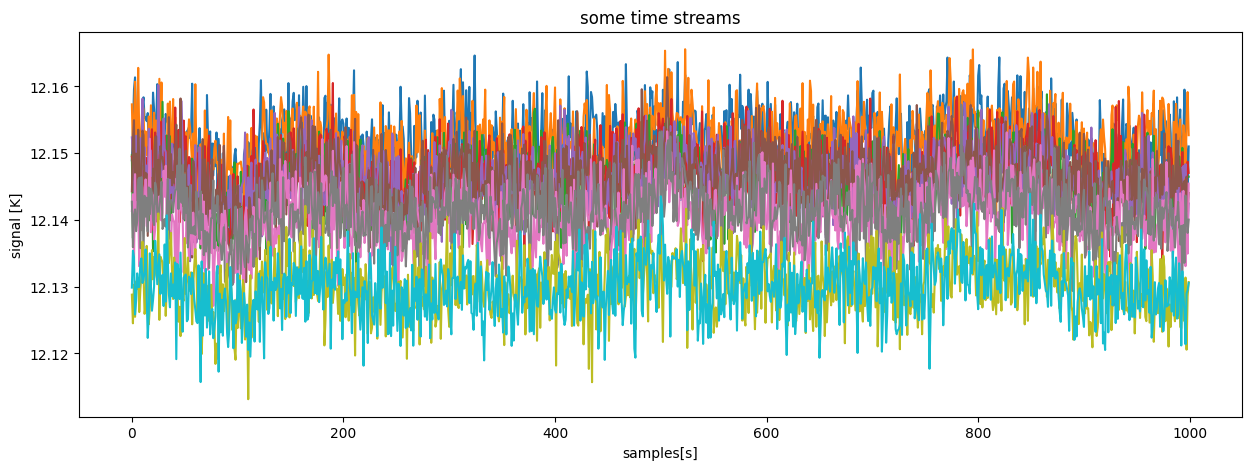

In [4]:
plt.figure(figsize=(15,5))
plt.plot(tod_1.signal[:10,:10**3].T)
plt.title('some time streams')
plt.xlabel('samples[s]')
plt.ylabel('signal [K]')

In [5]:
# power spectral density of the time streams

# recibe el .h5 file
def get_psd(tod):
    psd = np.abs(np.fft.fft(tod.signal, axis=-1))**2
    return psd
                                                                                    

psd_1 = get_psd(tod_1)
psd_2 = get_psd(tod_2)

Text(0.5, 1.0, 'PSD for 10 different detectors')

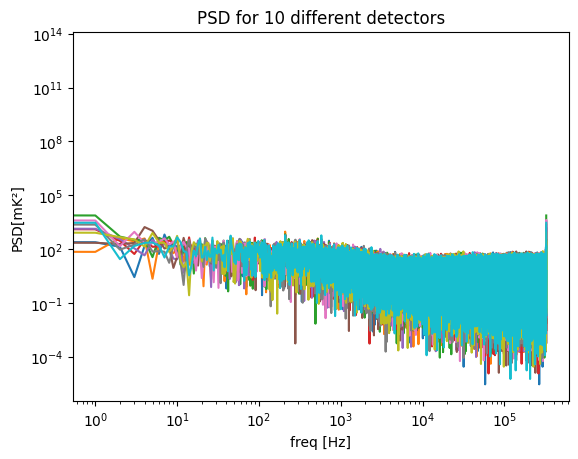

In [6]:
plt.loglog(psd_1[:10, :].T)
plt.xlabel('freq [Hz]')
plt.ylabel(r'PSD[mK²]')                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
plt.title('PSD for 10 different detectors')

Text(0.5, 1.0, 'PSD for 10 different detectors')

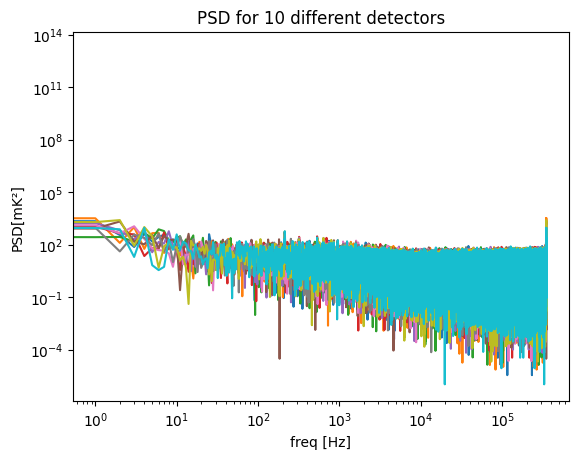

In [7]:
plt.loglog(psd_2[:10, :].T)
plt.xlabel('freq [Hz]')
plt.ylabel(r'PSD[mK²]')
plt.title('PSD for 10 different detectors')

In [73]:
# create a noise model from time streams

# empty noise models
noise_model_uncorrelated = mapmaking.NmatUncorr()
noise_model_correlated = mapmaking.NmatDetvecs()
noise_model_white = mapmaking.NmatWhite()
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## white ##
white_noise = noise_model_white.build(tod_1.signal, 200) 
uncorrelated_noise = noise_model_uncorrelated.build(tod_1.signal, 200)
correlated_noise = noise_model_correlated.build(tod_1.signal, 200)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [75]:
correlated_noise.V

array([[[4.4406055e+03],
        [4.4406055e+03],
        [4.4406055e+03],
        ...,
        [4.4406055e+03],
        [4.4406055e+03],
        [4.4406055e+03]],

       [[3.0884419e+03],
        [3.0884419e+03],
        [3.0884419e+03],
        ...,
        [3.0884419e+03],
        [3.0884419e+03],
        [3.0884419e+03]],

       [[1.7751997e+03],
        [1.7751997e+03],
        [1.7751997e+03],
        ...,
        [1.7751997e+03],
        [1.7751997e+03],
        [1.7751997e+03]],

       ...,

       [[1.5991357e-01],
        [1.5991357e-01],
        [1.5991357e-01],
        ...,
        [1.5991357e-01],
        [1.5991357e-01],
        [1.5991357e-01]],

       [[1.5993051e-01],
        [1.5993051e-01],
        [1.5993051e-01],
        ...,
        [1.5993051e-01],
        [1.5993051e-01],
        [1.5993051e-01]],

       [[1.5838036e-01],
        [1.5838036e-01],
        [1.5838036e-01],
        ...,
        [1.5838036e-01],
        [1.5838036e-01],
        [1.5838036e-01]]

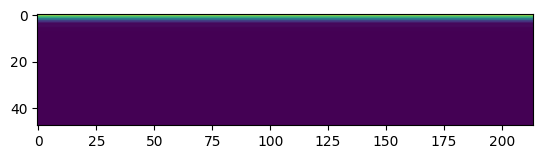

In [74]:
plt.imshow(correlated_noise.V)

In [47]:
len(correlated_noise.bins)

48

In [41]:
48*214

10272

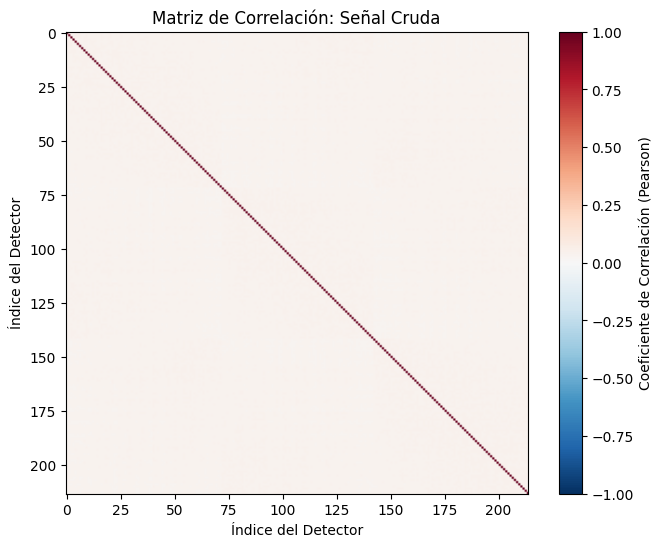

In [24]:
matriz_correlacion_cruda = np.corrcoef(tod_2.signal)

# 2. Ploteamos con imshow
plt.figure(figsize=(8, 6))
# Usamos un mapa de colores divergente (RdBu) centrado en 0
im = plt.imshow(matriz_correlacion_cruda, aspect='equal', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, label='Coeficiente de Correlación (Pearson)')

plt.title('Matriz de Correlación: Señal Cruda')
plt.xlabel('Índice del Detector')
plt.ylabel('Índice del Detector')
plt.show()

In [54]:


rutaTOD = '/home/mati/Documentos/PhD/códigos/simulaciones_SO/out_sat_test_/data'

TOD1 = rutaTOD + '/test-5-5_w31.h5'

tod_3 = load.load_toast_h5_file(TOD1,enhance=1)

In [63]:
timesamps = tod_3.timestamps
boresight = tod_3.boresight
signal = tod_3.signal
toast_focalplane  = tod_3.toast_focalplane
focal_plane = tod_3.focal_plane
numberDetectors = tod_3.dets
numberSamples = tod_3.samps

psd_3 = get_psd(tod_3)

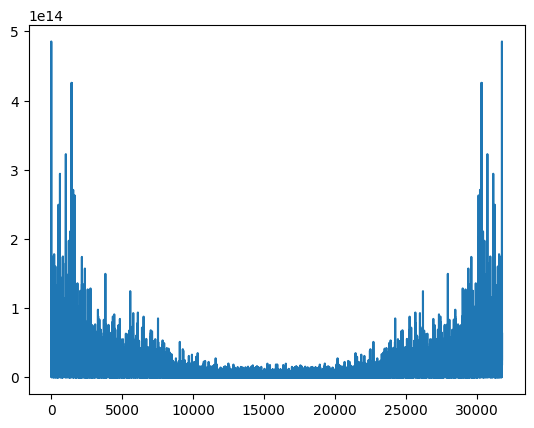

In [66]:
plt.plot(psd_3[20,:])

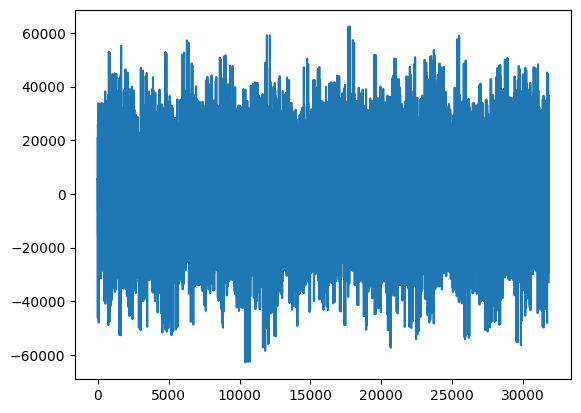

In [67]:
plt.plot(tod_3.signal[0,:])

In [76]:
## white ##
white_noise_3 = noise_model_white.build(tod_3.signal, 200) 
uncorrelated_noise_3 = noise_model_uncorrelated.build(tod_3.signal, 200)
correlated_noise_3 = noise_model_correlated.build(tod_3.signal, 200)     

In [90]:
correlated_noise_3.V[:, :, 12]

array([[-1.64773075e+06, -1.73369262e+06, -2.18167675e+06, ...,
         2.55802078e+05, -6.13687375e+05, -5.85990250e+05],
       [-1.91301727e+02, -2.01281921e+02, -2.53292923e+02, ...,
         2.96986523e+01, -7.12491760e+01, -6.80335388e+01],
       [-1.24958237e+02, -1.31477295e+02, -1.65450867e+02, ...,
         1.93991508e+01, -4.65399437e+01, -4.44394875e+01],
       ...,
       [-3.64805125e+05, -3.83836969e+05, -4.83019969e+05, ...,
         5.66341992e+04, -1.35869469e+05, -1.29737375e+05],
       [-3.16150750e+05, -3.32644281e+05, -4.18599156e+05, ...,
         4.90808477e+04, -1.17748445e+05, -1.12434188e+05],
       [-3.16443750e+05, -3.32952594e+05, -4.18987156e+05, ...,
         4.91263359e+04, -1.17857578e+05, -1.12538391e+05]],
      shape=(48, 28), dtype=float32)

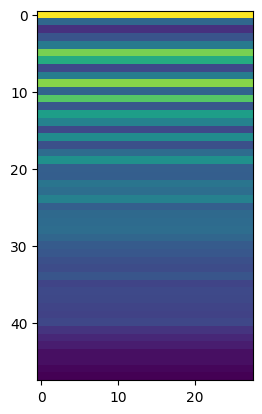

In [92]:
plt.imshow(correlated_noise_3.V[:,:,0])